In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import matplotlib.pyplot as plt
import kagglehub


c:\Users\Usuario\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

# 1. Descarga del dataset mediante la API de kagglehub
print("Descargando dataset de melanoma desde Kaggle...")
path = kagglehub.dataset_download("hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images")
print(f"Ruta base del caché de Kaggle: {path}\n")

# 2. Inspección dinámica de las carpetas internas
# Listamos el contenido para ver si las carpetas de train/test están en la raíz o dentro de otra subcarpeta
contenido_base = os.listdir(path)
print("Contenido directo en la raíz del dataset:", contenido_base)

# Si viene envuelto en una carpeta intermedia (como 'melanoma_cancer_dataset') entramos en ella
if len(contenido_base) == 1 and os.path.isdir(os.path.join(path, contenido_base[0])):
    ruta_inspeccion = os.path.join(path, contenido_base[0])
else:
    ruta_inspeccion = path

# Buscamos las carpetas de entrenamiento y prueba sin importar si se llaman 'train', 'Train', 'test' o 'Test'
carpetas_internas = os.listdir(ruta_inspeccion)
train_folder = next((c for c in carpetas_internas if c.lower() == 'train'), None)
test_folder = next((c for c in carpetas_internas if c.lower() == 'test'), None)

if not train_folder or not test_folder:
    raise FileNotFoundError("No se encontraron carpetas llamadas 'train' o 'test'. Revisa el listado de arriba.")

# Construimos las rutas absolutas finales listas para Keras
path_train = os.path.join(ruta_inspeccion, train_folder)
path_test = os.path.join(ruta_inspeccion, test_folder)

print(f"\n[Ruta Encontrada Exitosamente]")
print(f"-> Train: {path_train}")
print(f"-> Test:  {path_test}\n")

# 3. Configuración e Ingestión Automática con tf.keras
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

print("--- Cargando Conjunto de Entrenamiento (Split 80%) ---")
train_ds = tf.keras.utils.image_dataset_from_directory(
    path_train,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n--- Cargando Conjunto de Validación (Split 20%) ---")
val_ds = tf.keras.utils.image_dataset_from_directory(
    path_train,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("\n--- Cargando Conjunto de Prueba Final (Test) ---")
test_ds = tf.keras.utils.image_dataset_from_directory(
    path_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False # Mantener False para evaluar la matriz de confusión limpiamente al final
)

print(f"\n¡Clases detectadas en el árbol de directorios de Kaggle!: {train_ds.class_names}")

Descargando dataset de melanoma desde Kaggle...
Ruta base del caché de Kaggle: C:\Users\Usuario\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1

Contenido directo en la raíz del dataset: ['melanoma_cancer_dataset']

[Ruta Encontrada Exitosamente]
-> Train: C:\Users\Usuario\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset\train
-> Test:  C:\Users\Usuario\.cache\kagglehub\datasets\hasnainjaved\melanoma-skin-cancer-dataset-of-10000-images\versions\1\melanoma_cancer_dataset\test

--- Cargando Conjunto de Entrenamiento (Split 80%) ---
Found 9605 files belonging to 2 classes.
Using 7684 files for training.

--- Cargando Conjunto de Validación (Split 20%) ---
Found 9605 files belonging to 2 classes.
Using 1921 files for validation.

--- Cargando Conjunto de Prueba Final (Test) ---
Found 1000 files belonging to 2 classes.

¡Clases detectadas en el árbol de directorios de Kaggle!

Iniciando EDA global del 100% de los datos (Train + Test)...

-> Extrayendo datos del conjunto de ENTRENAMIENTO...
   Clase 'benign': 5000 imágenes detectadas.
   Clase 'malignant': 4605 imágenes detectadas.

-> Extrayendo datos del conjunto de TEST...
   Clase 'benign': 500 imágenes detectadas.
   Clase 'malignant': 500 imágenes detectadas.

¡Éxito! Análisis finalizado. Total de imágenes evaluadas: 10605


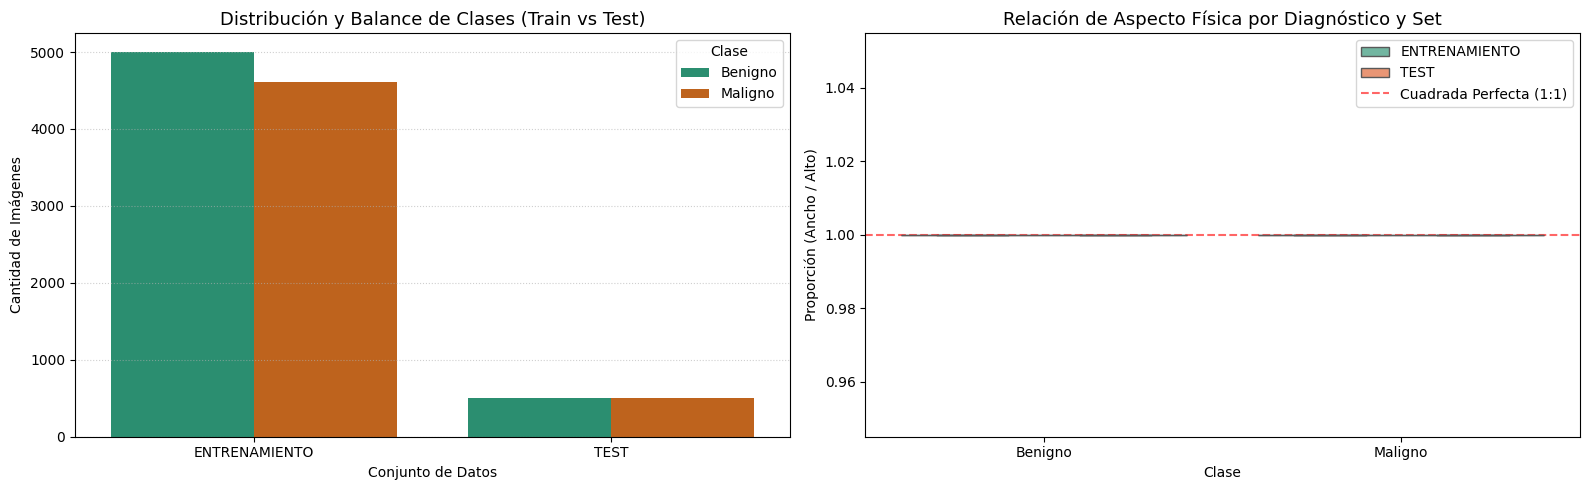

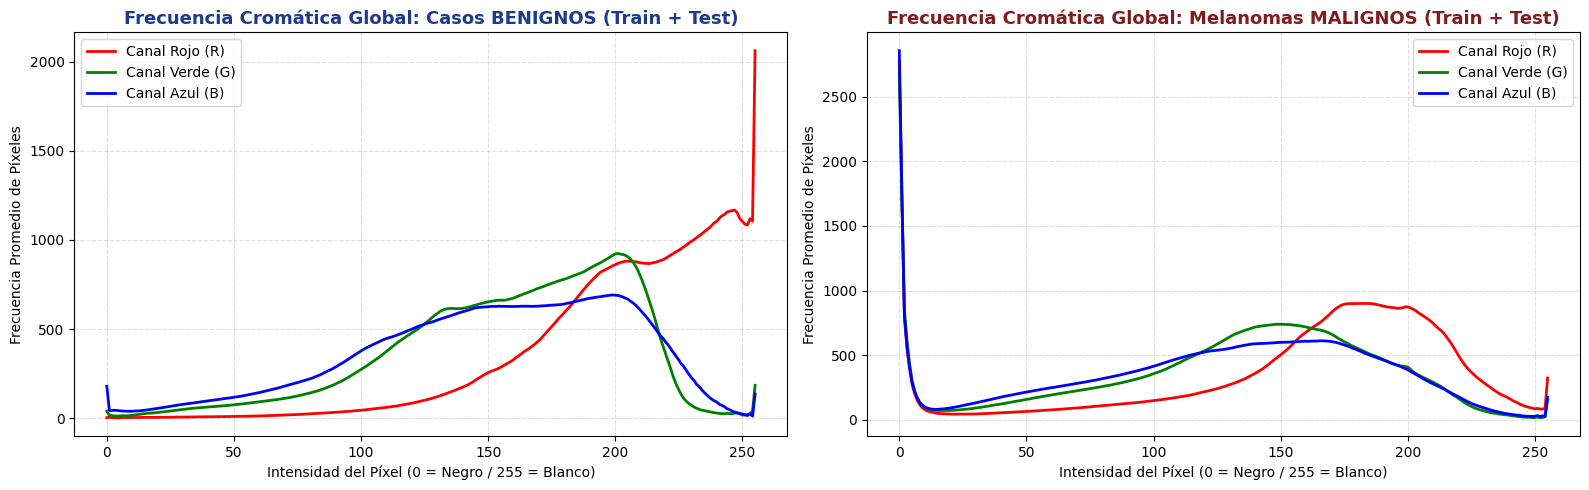

In [5]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Creamos una lista con ambas rutas raíz para barrer todo el dataset
rutas_a_analizar = [path_train, path_test]
print(f"Iniciando EDA global del 100% de los datos (Train + Test)...")

# ===================================================================
# 1. BARRIDO GENERAL Y EXTRACCIÓN DE METADATA (CONSOLIDADO)
# ===================================================================
datos_imagenes = []

# Inicializamos contenedores globales para los histogramas de color por clase
hist_benigno = {'R': np.zeros(256), 'G': np.zeros(256), 'B': np.zeros(256), 'conteo': 0}
hist_maligno = {'R': np.zeros(256), 'G': np.zeros(256), 'B': np.zeros(256), 'conteo': 0}

for ruta_base in rutas_a_analizar:
    tipo_set = "ENTRENAMIENTO" if "train" in ruta_base.lower() else "TEST"
    print(f"\n-> Extrayendo datos del conjunto de {tipo_set}...")
    
    for clase in os.listdir(ruta_base):
        ruta_clase = os.path.join(ruta_base, clase)
        if os.path.isdir(ruta_clase):
            archivos = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
            print(f"   Clase '{clase}': {len(archivos)} imágenes detectadas.")
            
            for archivo in archivos: 
                ruta_img = os.path.join(ruta_clase, archivo)
                try:
                    with Image.open(ruta_img) as img:
                        # 1.1 Metadata Geométrica y Estructural
                        ancho, alto = img.size
                        datos_imagenes.append({
                            'Set': tipo_set,
                            'Clase': 'Benigno' if clase.lower() == 'benign' else 'Maligno',
                            'Ancho': ancho,
                            'Alto': alto,
                            'Relacion_Aspecto': ancho / alto
                        })
                        
                        # 1.2 Metadata Cromática (Histograma PIL nativo RGB)
                        img_rgb = img.convert('RGB')
                        hist = img_rgb.histogram() # Vector plano de 768 posiciones (256 x 3)
                        
                        # Acumular frecuencias según patología real
                        if clase.lower() == 'benign':
                            hist_benigno['R'] += np.array(hist[0:256])
                            hist_benigno['G'] += np.array(hist[256:512])
                            hist_benigno['B'] += np.array(hist[512:768])
                            hist_benigno['conteo'] += 1
                        else:
                            hist_maligno['R'] += np.array(hist[0:256])
                            hist_maligno['G'] += np.array(hist[256:512])
                            hist_maligno['B'] += np.array(hist[512:768])
                            hist_maligno['conteo'] += 1
                except:
                    # Omitir de forma segura archivos corruptos si existieran
                    continue

# Crear DataFrame consolidado
df_eda_global = pd.DataFrame(datos_imagenes)

# Calcular promedios reales de los histogramas por canal de color
for canal in ['R', 'G', 'B']:
    if hist_benigno['conteo'] > 0: hist_benigno[canal] /= hist_benigno['conteo']
    if hist_maligno['conteo'] > 0: hist_maligno[canal] /= hist_maligno['conteo']

print(f"\n¡Éxito! Análisis finalizado. Total de imágenes evaluadas: {len(df_eda_global)}")

# ===================================================================
# 2. VISUALIZACIÓN DE COMPOSICIÓN Y GEOMETRÍA (TRAIN VS TEST)
# ===================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Balance de Clases comparando el set de Train vs Test
sns.countplot(data=df_eda_global, x='Set', hue='Clase', ax=ax1, palette='Dark2')
ax1.set_title('Distribución y Balance de Clases (Train vs Test)', fontsize=13)
ax1.set_xlabel('Conjunto de Datos')
ax1.set_ylabel('Cantidad de Imágenes')
ax1.grid(True, linestyle=':', alpha=0.6, axis='y')

# Gráfico B: Boxplot de Relación de Aspecto (Morfología de imágenes)
sns.boxplot(data=df_eda_global, x='Clase', y='Relacion_Aspecto', hue='Set', ax=ax2, palette='Set2')
ax2.axhline(1.0, color='red', linestyle='--', alpha=0.6, label='Cuadrada Perfecta (1:1)')
ax2.set_title('Relación de Aspecto Física por Diagnóstico y Set', fontsize=13)
ax2.set_ylabel('Proporción (Ancho / Alto)')
ax2.legend()

plt.tight_layout()
plt.show()

# ===================================================================
# 3. VISUALIZACIÓN DE FRECUENCIA CROMÁTICA GLOBAL SEPARADA
# ===================================================================
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico C: Histograma de Color Consolidado para Lunares BENIGNOS
ax3.plot(hist_benigno['R'], color='red', label='Canal Rojo (R)', linewidth=2)
ax3.plot(hist_benigno['G'], color='green', label='Canal Verde (G)', linewidth=2)
ax3.plot(hist_benigno['B'], color='blue', label='Canal Azul (B)', linewidth=2)
ax3.set_title('Frecuencia Cromática Global: Casos BENIGNOS (Train + Test)', fontsize=13, fontweight='bold', color='#1e3a8a')
ax3.set_xlabel('Intensidad del Píxel (0 = Negro / 255 = Blanco)')
ax3.set_ylabel('Frecuencia Promedio de Píxeles')
ax3.grid(True, linestyle='--', alpha=0.4)
ax3.legend()

# Gráfico D: Histograma de Color Consolidado para Melanomas MALIGNOS
ax4.plot(hist_maligno['R'], color='red', label='Canal Rojo (R)', linewidth=2)
ax4.plot(hist_maligno['G'], color='green', label='Canal Verde (G)', linewidth=2)
ax4.plot(hist_maligno['B'], color='blue', label='Canal Azul (B)', linewidth=2)
ax4.set_title('Frecuencia Cromática Global: Melanomas MALIGNOS (Train + Test)', fontsize=13, fontweight='bold', color='#7f1d1d')
ax4.set_xlabel('Intensidad del Píxel (0 = Negro / 255 = Blanco)')
ax4.set_ylabel('Frecuencia Promedio de Píxeles')
ax4.grid(True, linestyle='--', alpha=0.4)
ax4.legend()

plt.tight_layout()
plt.show()

Iniciando Auditoría Avanzada de Calidad y Criptografía de Imágenes...

 🚨 REPORTE DE CALIDAD DEL DATASET 🚨
Total de imágenes procesadas únicas: 10583
Archivos Corruptos detectados: 0
Archivos Duplicados (Clones) detectados: 22
  -> (Recomendación: Eliminar los duplicados antes de entrenar modelos finales)



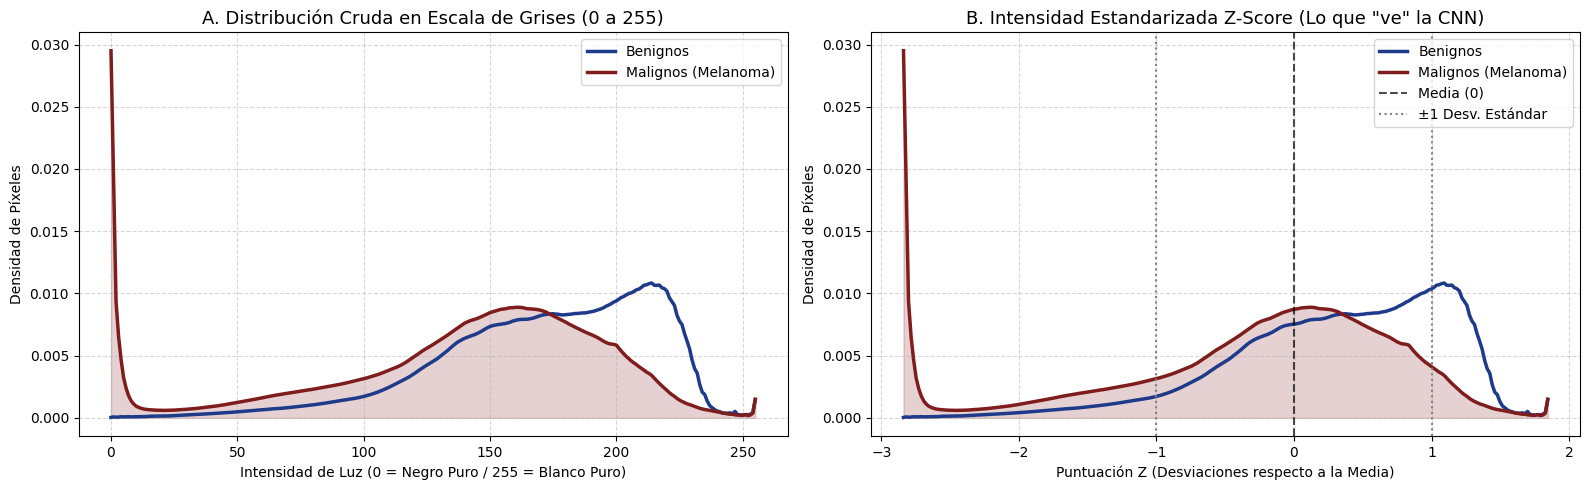

In [6]:
import os
import hashlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

print("Iniciando Auditoría Avanzada de Calidad y Criptografía de Imágenes...")

rutas_a_analizar = [path_train, path_test]

# ===================================================================
# 1. CONTENEDORES PARA LA AUDITORÍA
# ===================================================================
archivos_corruptos = []
archivos_duplicados = []
hashes_vistos = {} # Diccionario para almacenar las huellas digitales

# Contenedores para la Escala de Grises (256 niveles: 0 a 255)
hist_gris_benigno = np.zeros(256)
hist_gris_maligno = np.zeros(256)
pixeles_totales_benigno = 0
pixeles_totales_maligno = 0

# ===================================================================
# 2. MOTOR DE PROCESAMIENTO (VERIFICACIÓN, HASH Y GRISES)
# ===================================================================
for ruta_base in rutas_a_analizar:
    for clase in os.listdir(ruta_base):
        ruta_clase = os.path.join(ruta_base, clase)
        if os.path.isdir(ruta_clase):
            archivos = [f for f in os.listdir(ruta_clase) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
            es_maligno = (clase.lower() != 'benign')
            
            for archivo in archivos:
                ruta_img = os.path.join(ruta_clase, archivo)
                
                # --- A. DETECCIÓN DE CORRUPCIÓN ---
                try:
                    with Image.open(ruta_img) as img:
                        img.verify() # Comprueba la integridad estructural del archivo
                except Exception:
                    archivos_corruptos.append(ruta_img)
                    continue # Si está corrupto, lo saltamos
                
                # --- B. DETECCIÓN DE DUPLICADOS EXACTOS ---
                try:
                    with Image.open(ruta_img) as img:
                        # Extraemos los datos crudos y generamos un hash MD5
                        img_bytes = img.tobytes()
                        huella_digital = hashlib.md5(img_bytes).hexdigest()
                        
                        if huella_digital in hashes_vistos:
                            # ¡Clon detectado! Guardamos la ruta del original y la del clon
                            archivos_duplicados.append({'Original': hashes_vistos[huella_digital], 'Clon': ruta_img})
                            continue # Omitimos el duplicado para no sesgar la estadística de intensidad
                        else:
                            hashes_vistos[huella_digital] = ruta_img
                            
                        # --- C. TRANSFORMACIÓN A ESCALA DE GRISES ---
                        img_gris = img.convert('L') # 'L' es el modo Luma (Grayscale) en PIL
                        hist = img_gris.histogram()
                        
                        ancho, alto = img.size
                        total_pix = ancho * alto
                        
                        if es_maligno:
                            hist_gris_maligno += np.array(hist)
                            pixeles_totales_maligno += total_pix
                        else:
                            hist_gris_benigno += np.array(hist)
                            pixeles_totales_benigno += total_pix
                except Exception:
                    continue

# ===================================================================
# 3. REPORTE DE AUDITORÍA DE CALIDAD
# ===================================================================
print("\n" + "="*50)
print(" 🚨 REPORTE DE CALIDAD DEL DATASET 🚨")
print("="*50)
print(f"Total de imágenes procesadas únicas: {len(hashes_vistos)}")
print(f"Archivos Corruptos detectados: {len(archivos_corruptos)}")
print(f"Archivos Duplicados (Clones) detectados: {len(archivos_duplicados)}")
if len(archivos_duplicados) > 0:
    print("  -> (Recomendación: Eliminar los duplicados antes de entrenar modelos finales)")
print("="*50 + "\n")

# ===================================================================
# 4. PREPARACIÓN MATEMÁTICA PARA LA ESTANDARIZACIÓN (Z-SCORE)
# ===================================================================
# Normalizamos los histogramas por la cantidad total de píxeles
densidad_benigno = hist_gris_benigno / pixeles_totales_benigno
densidad_maligno = hist_gris_maligno / pixeles_totales_maligno

# Calculamos Media y Desviación Estándar teórica global (Rango 0 a 1)
eje_x_original = np.arange(256) / 255.0 # Mapeamos de [0, 255] a [0.0, 1.0]

media_global = np.average(eje_x_original, weights=(densidad_benigno + densidad_maligno)/2)
varianza_global = np.average((eje_x_original - media_global)**2, weights=(densidad_benigno + densidad_maligno)/2)
std_global = np.sqrt(varianza_global)

# Mapeamos el Eje X con la fórmula Z-Score: (X - Media) / Std
eje_x_estandarizado = (eje_x_original - media_global) / std_global

# ===================================================================
# 5. VISUALIZACIÓN DE INTENSIDADES (CRUDAS VS ESTANDARIZADAS)
# ===================================================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico A: Distribución en Escala de Grises CRUDA
ax1.plot(np.arange(256), densidad_benigno, color='#1e3a8a', label='Benignos', linewidth=2.5)
ax1.plot(np.arange(256), densidad_maligno, color='#7f1d1d', label='Malignos (Melanoma)', linewidth=2.5)
ax1.fill_between(np.arange(256), densidad_maligno, alpha=0.2, color='#7f1d1d')
ax1.set_title('A. Distribución Cruda en Escala de Grises (0 a 255)', fontsize=13)
ax1.set_xlabel('Intensidad de Luz (0 = Negro Puro / 255 = Blanco Puro)')
ax1.set_ylabel('Densidad de Píxeles')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Gráfico B: Distribución de Intensidad ESTANDARIZADA (Z-Score)
ax2.plot(eje_x_estandarizado, densidad_benigno, color='#1e3a8a', label='Benignos', linewidth=2.5)
ax2.plot(eje_x_estandarizado, densidad_maligno, color='#7f1d1d', label='Malignos (Melanoma)', linewidth=2.5)
ax2.fill_between(eje_x_estandarizado, densidad_maligno, alpha=0.2, color='#7f1d1d')

# Líneas de control estadístico
ax2.axvline(0, color='black', linestyle='--', label='Media (0)', alpha=0.7)
ax2.axvline(-1, color='gray', linestyle=':', label='±1 Desv. Estándar')
ax2.axvline(1, color='gray', linestyle=':')

ax2.set_title('B. Intensidad Estandarizada Z-Score (Lo que "ve" la CNN)', fontsize=13)
ax2.set_xlabel('Puntuación Z (Desviaciones respecto a la Media)')
ax2.set_ylabel('Densidad de Píxeles')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

Mostrando 5 ejemplo(s) de imágenes duplicadas (Original vs Clon)...



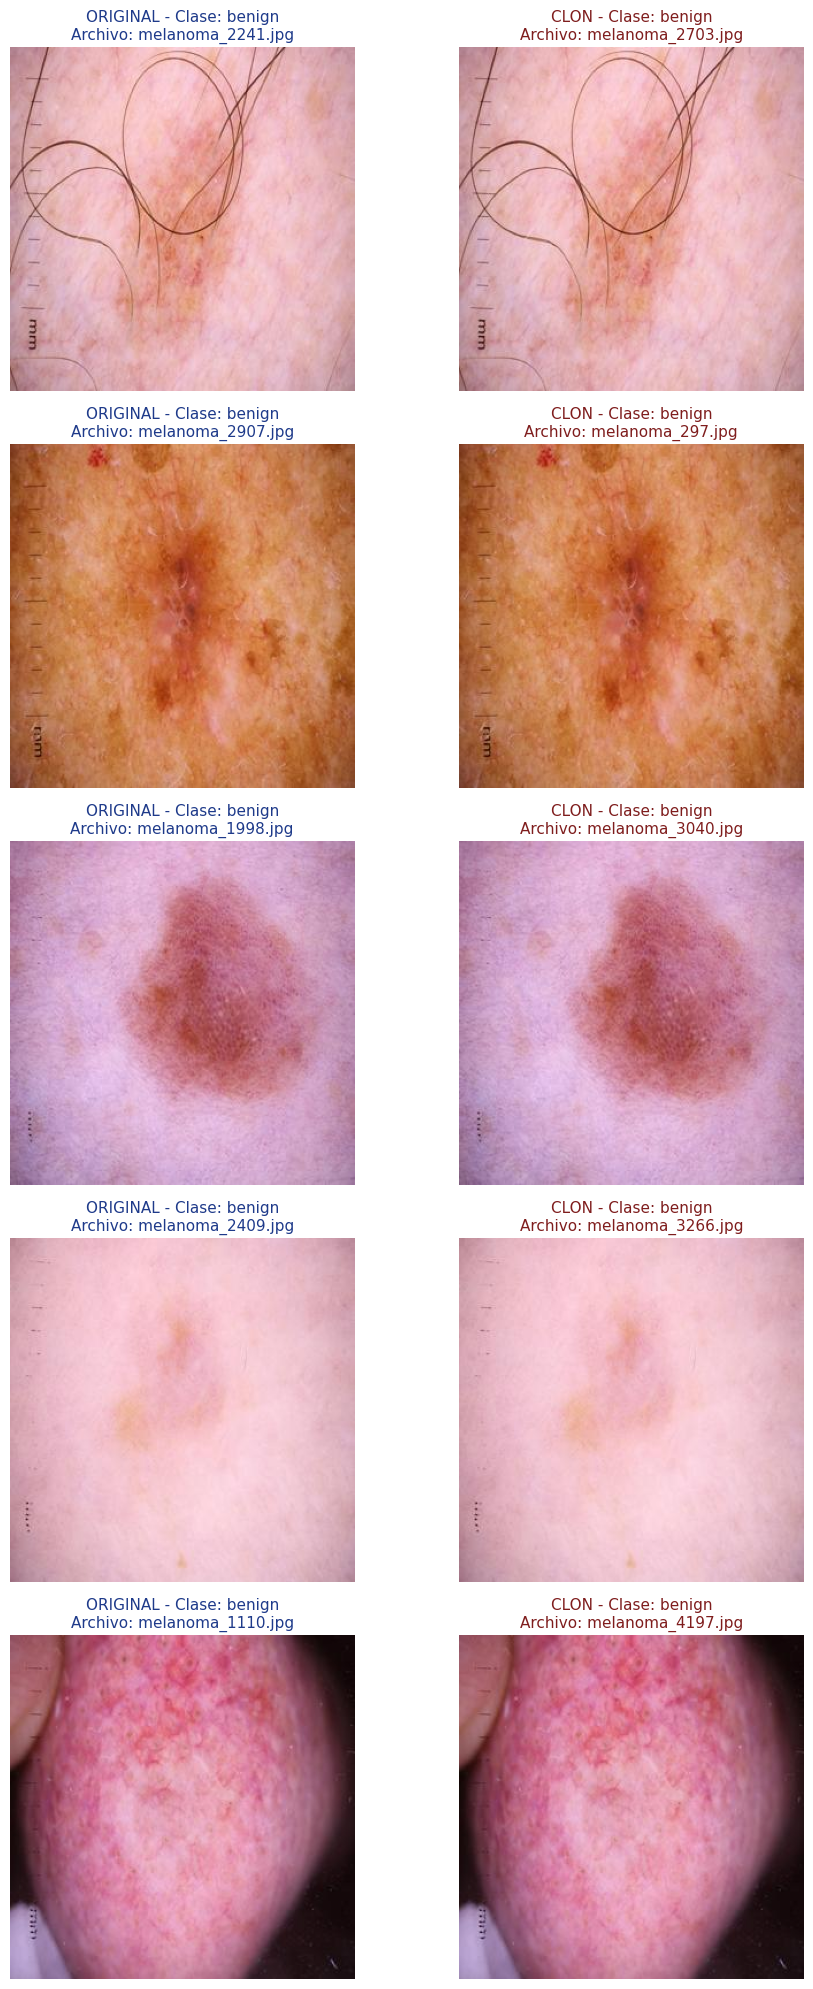

In [7]:
import os
import matplotlib.pyplot as plt
from PIL import Image

# Verificamos si la lista de la celda anterior tiene datos
if len(archivos_duplicados) == 0:
    print("¡Genial! El análisis previo no encontró imágenes duplicadas (clones) en tu dataset.")
else:
    # Mostraremos un máximo de 5 pares para no saturar la memoria RAM ni la pantalla
    num_ejemplos = min(5, len(archivos_duplicados))
    print(f"Mostrando {num_ejemplos} ejemplo(s) de imágenes duplicadas (Original vs Clon)...\n")
    
    # Creamos una cuadrícula dinámica: N filas y 2 columnas
    fig, axes = plt.subplots(num_ejemplos, 2, figsize=(10, 4 * num_ejemplos))
    
    # Aseguramos que axes sea iterable incluso si solo hay 1 fila
    if num_ejemplos == 1:
        axes = [axes]
        
    for i in range(num_ejemplos):
        ruta_original = archivos_duplicados[i]['Original']
        ruta_clon = archivos_duplicados[i]['Clon']
        
        try:
            # Cargar ambas imágenes
            img_orig = Image.open(ruta_original)
            img_clon = Image.open(ruta_clon)
            
            # Extraer el nombre del archivo y la clase desde la ruta para las etiquetas
            nombre_orig = os.path.basename(ruta_original)
            clase_orig = os.path.basename(os.path.dirname(ruta_original))
            
            nombre_clon = os.path.basename(ruta_clon)
            clase_clon = os.path.basename(os.path.dirname(ruta_clon))
            
            # Dibujar la imagen Original (Izquierda)
            axes[i][0].imshow(img_orig)
            axes[i][0].set_title(f"ORIGINAL - Clase: {clase_orig}\nArchivo: {nombre_orig}", fontsize=11, color='#1e3a8a')
            axes[i][0].axis('off') # Ocultar la regla de píxeles
            
            # Dibujar el Clon (Derecha)
            axes[i][1].imshow(img_clon)
            axes[i][1].set_title(f"CLON - Clase: {clase_clon}\nArchivo: {nombre_clon}", fontsize=11, color='#7f1d1d')
            axes[i][1].axis('off')
            
        except Exception as e:
            print(f"Error al cargar el par {i}: {e}")
            
    plt.tight_layout()
    plt.show()

In [8]:
# Valores estándar de la industria para la escala de colores RGB
MEAN = tf.constant([0.485, 0.456, 0.406], dtype=tf.float32)
STD = tf.constant([0.229, 0.224, 0.225], dtype=tf.float32)

def normalizar_canais_rgb(images, labels):
    # 1. Convertimos los píxeles a flotantes en rango [0, 1] como base
    images = tf.cast(images, tf.float32) / 255.0
    
    # 2. Aplicamos la fórmula Score-Z a cada canal de color
    images = (images - MEAN) / STD
    
    return images, labels

In [9]:
# Aplicar la normalización RGB en los pipelines de datos
train_ds_norm = train_ds.map(normalizar_canais_rgb, num_parallel_calls=tf.data.AUTOTUNE)
val_ds_norm = val_ds.map(normalizar_canais_rgb, num_parallel_calls=tf.data.AUTOTUNE)
test_ds_norm = test_ds.map(normalizar_canais_rgb, num_parallel_calls=tf.data.AUTOTUNE)

# Optimizar el flujo de memoria en Python 3.12 (Prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds_norm = train_ds_norm.prefetch(buffer_size=AUTOTUNE)
val_ds_norm = val_ds_norm.prefetch(buffer_size=AUTOTUNE)
test_ds_norm = test_ds_norm.prefetch(buffer_size=AUTOTUNE)

print("¡Normalización avanzada de escala de colores RGB aplicada con éxito!")

¡Normalización avanzada de escala de colores RGB aplicada con éxito!


In [10]:
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2

# Capa de Aumento de Datos (Las imágenes ya entran normalizadas por color)
data_augmentation_melanoma = models.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(factor=0.15, fill_mode="reflect"),
    layers.RandomZoom(height_factor=0.10, fill_mode="reflect")
])

def crear_cnn_melanoma_rgb(input_shape=(224, 224, 3)):
    model = models.Sequential()
    
    # Capa de entrada
    model.add(layers.Input(shape=input_shape))
    
    # Bloque de aumento de datos
    model.add(data_augmentation_melanoma)
    
    # BLOQUE CONVOLUCIONAL 1
    model.add(layers.ZeroPadding2D(padding=2))
    model.add(layers.Conv2D(32, (3, 3), padding='valid', kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # BLOQUE CONVOLUCIONAL 2
    model.add(layers.ZeroPadding2D(padding=2))
    model.add(layers.Conv2D(64, (3, 3), padding='valid', kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # BLOQUE CONVOLUCIONAL 3
    model.add(layers.ZeroPadding2D(padding=2))
    model.add(layers.Conv2D(128, (3, 3), padding='valid', kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # GAP contra Overfitting (Crucial)
    model.add(layers.GlobalAveragePooling2D())
    
    # CLASIFICADOR (HEAD REGULARIZADO)
    model.add(layers.Dense(128, kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    
    # SALIDA BINARIA (1 neurona con activación Sigmoide)
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

# Instanciar y compilar
cnn_melanoma_rgb = crear_cnn_melanoma_rgb()
cnn_melanoma_rgb.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ===================================================================
# 1. ARQUITECTURA DE LA CNN CON GAP Y WEIGHT DECAY (L2)
# ===================================================================
def crear_cnn_melanoma_final(input_shape=(224, 224, 3)):
    model = models.Sequential()
    
    # Capa de entrada
    model.add(layers.Input(shape=input_shape))
    
    # Capa de aumento de datos (definida previamente)
    model.add(data_augmentation_melanoma)
    
    # --- BLOQUE CONVOLUCIONAL 1 ---
    model.add(layers.ZeroPadding2D(padding=2))
    # Aplicamos Weight Decay (l2) directo en el kernel convolucional
    model.add(layers.Conv2D(32, (3, 3), padding='valid', kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # --- BLOQUE CONVOLUCIONAL 2 ---
    model.add(layers.ZeroPadding2D(padding=2))
    model.add(layers.Conv2D(64, (3, 3), padding='valid', kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # --- BLOQUE CONVOLUCIONAL 3 ---
    model.add(layers.ZeroPadding2D(padding=2))
    model.add(layers.Conv2D(128, (3, 3), padding='valid', kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.MaxPooling2D(pool_size=(2, 2)))
    
    # ===============================================================
    # REDUCCIÓN ESTRUCTURAL CRUCIAL: Global Average Pooling (GAP)
    # ===============================================================
    # Reemplaza a Flatten(). Si la última capa entrega un mapa de 15x15x128,
    # GAP colapsa las dimensiones espaciales sacando el promedio de cada canal,
    # entregando un vector compacto de solo 128 elementos a la salida.
    model.add(layers.GlobalAveragePooling2D())
    
    # --- CLASIFICADOR CENTRAL (HEAD) ---
    # También añadimos L2 regularización a los pesos de la capa densa
    model.add(layers.Dense(128, kernel_regularizer=l2(1e-3)))
    model.add(layers.BatchNormalization())
    model.add(layers.Activation('relu'))
    model.add(layers.Dropout(0.5))
    
    # --- CAPA DE SALIDA BINARIA ---
    model.add(layers.Dense(1, activation='sigmoid'))
    
    return model

# 2. INSTANCIAR Y COMPILAR EL MODELO
# -------------------------------------------------------------------
modelo_final = crear_cnn_melanoma_final()

modelo_final.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy', # Métrica matemática ideal para clasificación binaria
    metrics=['accuracy']
)

# Imprimir el resumen para auditar la reducción extrema de parámetros
modelo_final.summary()

# ===================================================================
# 2. CONFIGURACIÓN DE CALLBACKS (Vigilantes del entrenamiento)
# ===================================================================
callbacks_final = [
    # Detiene el entrenamiento si el val_loss no mejora en 10 épocas
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    
    # Reduce el learning rate a la mitad si el aprendizaje se estanca
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1),
    
    # Guarda en disco duro solo el archivo con la mejor precisión alcanzada
    ModelCheckpoint('mejor_modelo_melanoma_gap_l2.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]

# ===================================================================
# 3. LANZAR EL ENTRENAMIENTO DEFINITIVO
# ===================================================================
print("\nIniciando entrenamiento con GAP y Weight Decay sobre escala RGB...")
EPOCHS = 10
BATCH_SIZE = 32

history_final = modelo_final.fit(
    train_ds_norm,                 # Dataset de entrenamiento normalizado por canal
    validation_data=val_ds_norm,   # Dataset de validación normalizado por canal
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks_final,
    verbose=1
)

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_1 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_6                │ (None, 228, 228, 3)    │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 226, 226, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 226, 226, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 226, 226, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 113, 113, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_7                │ (None, 117, 117, 32)   │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 115, 115, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 115, 115, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 115, 115, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 57, 57, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d_8                │ (None, 61, 61, 64)     │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 59, 59, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 59, 59, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 59, 59, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 29, 29, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             

 Total params: 111,297 (434.75 KB)

 Trainable params: 110,593 (432.00 KB)

 Non-trainable params: 704 (2.75 KB)


Iniciando entrenamiento con GAP y Weight Decay sobre escala RGB...
Epoch 1/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7920 - loss: 0.7021
Epoch 1: val_accuracy improved from None to 0.83498, saving model to mejor_modelo_melanoma_gap_l2.keras

Epoch 1: finished saving model to mejor_modelo_melanoma_gap_l2.keras
241/241 ━━━━━━━━━━━━━━━━━━━━ 473s 2s/step - accuracy: 0.8048 - loss: 0.6676 - val_accuracy: 0.8350 - val_loss: 0.5830 - learning_rate: 0.0010
Epoch 2/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8291 - loss: 0.5878
Epoch 2: val_accuracy did not improve from 0.83498
241/241 ━━━━━━━━━━━━━━━━━━━━ 467s 2s/step - accuracy: 0.8285 - loss: 0.5673 - val_accuracy: 0.8303 - val_loss: 0.5109 - learning_rate: 0.0010
Epoch 3/10
241/241 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8254 - loss: 0.5257
Epoch 3: val_accuracy improved from 0.83498 to 0.85008, saving model to mejor_modelo_melanoma_gap_l2.keras

Epoch 3: finished saving model to mejor_modelo_melanoma_gap_

--- Evaluando el modelo en el conjunto de prueba (Test) ---
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 325ms/step - accuracy: 0.8870 - loss: 0.3200

Precisión Global en Test (Accuracy): 88.70%
Pérdida en Test (Loss): 0.3200

32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 358ms/step

=== REPORTE DE CLASIFICACIÓN (MÉTRICAS DETALLADAS) ===
              precision    recall  f1-score   support

     Benigno       0.85      0.95      0.89       500
     Maligno       0.94      0.83      0.88       500

    accuracy                           0.89      1000
   macro avg       0.89      0.89      0.89      1000
weighted avg       0.89      0.89      0.89      1000



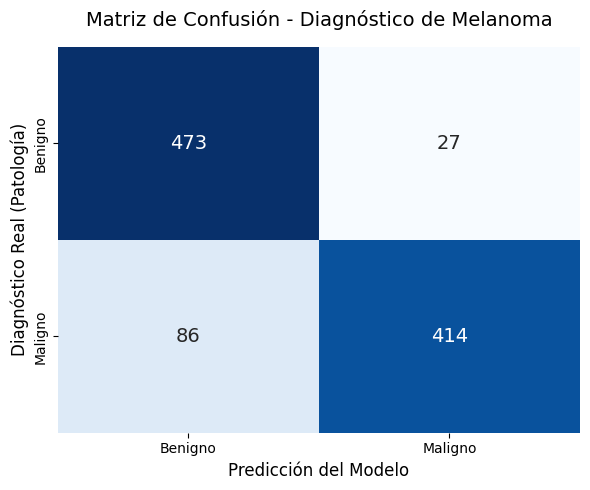

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ===================================================================
# 1. EVALUACIÓN GENERAL EN EL CONJUNTO DE TEST
# ===================================================================
print("--- Evaluando el modelo en el conjunto de prueba (Test) ---")
test_loss, test_acc = modelo_final.evaluate(test_ds_norm, verbose=1)
print(f"\nPrecisión Global en Test (Accuracy): {test_acc * 100:.2f}%")
print(f"Pérdida en Test (Loss): {test_loss:.4f}\n")

# ===================================================================
# 2. EXTRACCIÓN DE ETIQUETAS REALES Y PREDICCIONES
# ===================================================================
# Extraemos las etiquetas verdaderas del dataset mapeado
y_verdaderas = []
for _, labels in test_ds_norm:
    y_verdaderas.extend(labels.numpy())
y_verdaderas = np.array(y_verdaderas)

# Generamos las predicciones probabilísticas del modelo (salidas de la sigmoide)
predicciones_prob = modelo_final.predict(test_ds_norm, verbose=1)

# Al ser salida sigmoide [0.0, 1.0], usamos el umbral clásico de 0.5 para binarizar:
# Si prob >= 0.5 -> 1 (Malignant), de lo contrario -> 0 (Benign)
y_predichas = (predicciones_prob >= 0.5).astype(int).flatten()

# Nombres de las clases en orden alfabético estricto (coincide con Keras)
nombres_clases = ['Benigno', 'Maligno']

# ===================================================================
# 3. REPORTE DE CLASIFICACIÓN (Métricas Médicas Avanzadas)
# ===================================================================
print("\n=== REPORTE DE CLASIFICACIÓN (MÉTRICAS DETALLADAS) ===")
print(classification_report(y_verdaderas, y_predichas, target_names=nombres_clases))

# ===================================================================
# 4. MATRIZ DE CONFUSIÓN VISUAL
# ===================================================================
# Calculamos la matriz con scikit-learn
cm = confusion_matrix(y_verdaderas, y_predichas)

# Graficamos con Seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=nombres_clases, 
    yticklabels=nombres_clases,
    cbar=False,
    annot_kws={"size": 14}
)
plt.title('Matriz de Confusión - Diagnóstico de Melanoma', fontsize=14, pad=15)
plt.xlabel('Predicción del Modelo', fontsize=12)
plt.ylabel('Diagnóstico Real (Patología)', fontsize=12)
plt.tight_layout()
plt.show()